# Modeling World Cup Scoring Average using FIFA Ranking Points & Top 5 League Roster, 2010-2022
This notebook builds on the work in the exploratory notebooks `wc_2018_exploration`, `wc_2022_exploration`, and `wc_2022_player_level` to fully explore how well FIFA rank at the beginning of the tournament (a proxy for the nation's performance in past international matches) and number of rostered players from the Top 5 Leagues of European Club Football (a proxy for player strength) can predict World Cup Scoring Average, defined as the team's total goals scored - total goals conceded, divided by games played, across the tournament. A few notes:
- Initial exploration suggested that using FIFA Ranking Points, rather than the ordinal rank, may give better results, so that is the approach that will be pursued here.
- Much of the code here is copied, with small adaptations, from the exploratory notebooks referenced above; the code is more thoroughly documented with longer markdown explanations there.


In [1]:
# Import statements:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Setup part 1: Creating the Y vector
The below code is adapted from the `wc_2022_exploration` notebook. It first creates a series of 2D arrays, in which each row represents the performance of a particular nation during a particular World Cup for the four tournaments we are studying. Each row contains a team name, total number of World Cup matches played by that team that year, the team's total goals scored and total goals conceded across that tournament, and their scoring average for that tournament, which is derived from the prior three values. Because this data is being aggregated from a variety of sources, the ordering of team names within a particular year's data isn't consistent across all four sets of results. Therefore, the precise arrangement of teams in each of the four segments of the data will need to be noted and retained for later use to ensure that the X Matrix values are properly ordered.

From these 2D arrays of detailed results we derive a 1D vector of the 128 scoring average values, which will be used as the outcome variable for later modeling efforts. In this step we will also visualize and standardize the data within this vector.

For the 2022 and 2018 results, we're working with `.csv` files sourced from Kaggle, as specified in our `citations.txt`; for the 2014 and 2010 results, we've transcribed the necessary data from <https://fbref.com>.


### Tournament results arrays

First, we create the arrays with the relevant data from each of the 2010, 2014, 2018, and 2022 World Cups. Each row of each array contains the following data: team name, matches played, total goals scored, total goals conceded, and scoring average, where scoring average is defined as total goals scored minus total goals conceded, divided by matches played.

In [2]:
# Each row of each team_results array contains the following data:
# [team_name, matches_played, goals_scored, goals_conceded, scoring_average]

# The following data is transcribed from fbref.com's 2010 World Cup data
# Note the circumflex in Côte d'Ivoire! It's needed to match the style in the FIFA rankings csv.
team_list_2010 = ['Algeria', 'Argentina', 'Australia', 'Brazil', 'Cameroon', 'Chile', "Côte d'Ivoire",
                    'Denmark', 'England', 'France', 'Germany', 'Ghana', 'Greece', 'Honduras', 'Italy',
                    'Japan', 'Korea DPR', 'Korea Republic', 'Mexico', 'Netherlands', 'New Zealand',
                    'Nigeria', 'Paraguay', 'Portugal', 'Serbia', 'Slovakia', 'Slovenia', 'South Africa',
                    'Spain', 'Switzerland', 'USA', 'Uruguay']

team_results_2010 = [
    ['Algeria', 3, 0, 2, (2-0)/3],
    ['Argentina', 5, 9, 6, (9-6)/5],
    ['Australia', 3, 3, 6, (3-6)/3],
    ['Brazil', 5, 9, 4, (9-5)/5],
    ['Cameroon', 3, 2, 5, (2-5)/3],
    ['Chile', 4, 3, 5, (3-5)/4],
    ["Côte d'Ivoire", 3, 4, 3, (4-3)/3],
    ['Denmark', 3, 3, 5, (3-5)/3],
    ['England', 4, 3, 5, (3-5)/4],
    ['France', 3, 1, 4, (1-4)/3],
    ['Germany', 7, 16, 5, (16-5)/7],
    ['Ghana', 5, 5, 4, (5-4)/5],
    ['Greece', 3, 2, 5, (2-5)/3],
    ['Honduras', 3, 0, 3, (0-3)/3],
    ['Italy', 3, 4, 5, (4-5)/3],
    ['Japan', 4, 4, 2, (4-2)/3],
    ['Korea DPR', 3, 1, 12, (1-12)/3],
    ['Korea Republic', 4, 6, 7, (6-7)/4],
    ['Mexico', 4, 4, 5, (4-5)/4],
    ['Netherlands', 7, 11, 6, (11-6)/7],
    ['New Zealand', 3, 2, 2, (2-2)/3],
    ['Nigeria', 3, 3, 5, (3-5)/3],
    ['Paraguay', 5, 3, 2, (3-2)/5],
    ['Portugal', 4, 7, 1, (7-1)/4],
    ['Serbia', 3, 2, 3, (2-3)/3],
    ['Slovakia', 4, 5, 7, (5-7)/4],
    ['Slovenia', 3, 3, 3, (3-3)/3],
    ['South Africa', 3, 3, 5, (3-5)/3],
    ['Spain', 7, 8, 2, (8-2)/7],
    ['Switzerland', 3, 1, 1, 0],
    ['USA', 4, 5, 5, 0],
    ['Uruguay', 7, 11, 8, (11-8)/7]
]

# The following data is transcribed from fbref.com's 2014 World Cup data.
# Note the circumflex in Côte d'Ivoire! It's needed to match the style in the FIFA rankings csv.
team_list_2014 = ['Algeria', 'Argentina', 'Australia', 'Belgium', 'Bosnia and Herzegovina',
                    'Brazil', 'Cameroon', 'Chile', 'Colombia', 'Costa Rica', "Côte d'Ivoire",
                    'Croatia', 'Ecuador', 'England', 'France', 'Germany', 'Ghana', 'Greece',
                    'Honduras', 'IR Iran', 'Italy', 'Japan', 'Korea Republic', 'Mexico',
                    'Netherlands', 'Nigeria', 'Portugal', 'Russia', 'Spain', 'Switzerland',
                    'USA', 'Uruguay']
team_results_2014 = [
    ['Algeria', 4, 7, 7, 0],
    ['Argentina', 7, 7, 4, (7-4)/7],
    ['Australia', 3, 3, 9, (3-9)/3],
    ['Belgium', 5, 6, 3, (6-3)/5],
    ['Bosnia and Herzegovina', 3, 4, 3, (4-3)/3],
    ['Brazil', 7, 11, 13, (11-13)/7],
    ['Cameroon', 3, 1, 9, (1-9)/3],
    ['Chile', 4, 6, 4, (6-4)/4],
    ['Colombia', 5, 12, 4, (12-4)/5],
    ['Costa Rica', 5, 5, 2, (5-2)/5],
    ["Côte d'Ivoire", 3, 4, 5, (4-5)/3],
    ['Croatia', 3, 5, 6, (5-6)/3],
    ['Ecuador', 3, 3, 3, (3-3)/3],
    ['England', 3, 2, 4, (2-4)/3],
    ['France', 5, 8, 3, (8-3)/5],
    ['Germany', 7, 18, 4, (18-4)/7],
    ['Ghana', 3, 4, 5, (4-5)/3],
    ['Greece', 4, 3, 5, (3-5)/4],
    ['Honduras', 3, 1, 7, (1-7)/3],
    ['IR Iran', 3, 1, 4, (1-4)/3],
    ['Italy', 3, 2, 3, (2-3)/3],
    ['Japan', 3, 2, 6, (2-6)/3],
    ['Korea Republic', 3, 3, 6, (3-6)/3],
    ['Mexico', 4, 5, 3, (5-3)/4],
    ['Netherlands', 7, 15, 4, (15-4)/7],
    ['Nigeria', 4, 3, 4, (3-4)/4],
    ['Portugal', 3, 3, 7, (3-7)/3],
    ['Russia', 3, 2, 3, (2-3)/3],
    ['Spain', 3, 4, 7, (4-7)/3],
    ['Switzerland', 4, 7, 7, 0],
    ['USA', 4, 5, 6, (5-6)/4],
    ['Uruguay', 4, 4, 6, (4-6)/4]
]

# Next we construct the 2018 array from the wc_2018 csv
wc_2018 = pd.read_csv('wc_2018.csv')
team_list_2018 = wc_2018['Team'].unique()
team_results_2018 = []
for team in team_list_2018:
    games = 0
    goals_scored = 0
    goals_allowed = 0
    for i in range(wc_2018.shape[0]):
        if wc_2018.iloc[i, 2]==team:
            games += 1
            goals_scored += wc_2018.iloc[i, 8]
            goals_allowed += wc_2018.iloc[i, 9]
    score_average = (goals_scored/games - goals_allowed/games)
    team_results_2018.append([team, games, goals_scored, goals_allowed, score_average])

# Finally we construct the 2022 array from the wc_2022 csv
wc_2022 = pd.read_csv('wc_2022.csv')
team_list_2022 = wc_2022['team1'].unique()
team_results_2022 = []
for team in team_list_2022:
    games = 0
    goals_scored = 0
    goals_allowed = 0
    for i in range(wc_2022.shape[0]):
        if wc_2022.iloc[i, 0]==team:
            games += 1
            goals_scored += wc_2022.iloc[i, 5]
            goals_allowed += wc_2022.iloc[i, 6]
        elif wc_2022.iloc[i, 1]==team:
            games += 1
            goals_scored += wc_2022.iloc[i, 6]
            goals_allowed += wc_2022.iloc[i, 5]
    score_average = (goals_scored/games - goals_allowed/games)
    team_results_2022.append([team, games, goals_scored, goals_allowed, score_average])

# Prior data exploration revealed that two of the 2022 team names need to be edited
# Otherwise this data won't match the rankings data used later
team_list_2022[3] = 'USA'
team_list_2022[25] = 'IR IRAN'
team_results_2022[3][0] = 'USA'
team_results_2022[25][0] = 'IR IRAN'

In [3]:
print("2010 results array:")
print(team_results_2010)
print("2014 results array:")
print(team_results_2014)
print("2018 results array:")
print(team_results_2018)
print("2022 results array:")
print(team_results_2022)

2010 results array:
[['Algeria', 3, 0, 2, 0.6666666666666666], ['Argentina', 5, 9, 6, 0.6], ['Australia', 3, 3, 6, -1.0], ['Brazil', 5, 9, 4, 0.8], ['Cameroon', 3, 2, 5, -1.0], ['Chile', 4, 3, 5, -0.5], ["Côte d'Ivoire", 3, 4, 3, 0.3333333333333333], ['Denmark', 3, 3, 5, -0.6666666666666666], ['England', 4, 3, 5, -0.5], ['France', 3, 1, 4, -1.0], ['Germany', 7, 16, 5, 1.5714285714285714], ['Ghana', 5, 5, 4, 0.2], ['Greece', 3, 2, 5, -1.0], ['Honduras', 3, 0, 3, -1.0], ['Italy', 3, 4, 5, -0.3333333333333333], ['Japan', 4, 4, 2, 0.6666666666666666], ['Korea DPR', 3, 1, 12, -3.6666666666666665], ['Korea Republic', 4, 6, 7, -0.25], ['Mexico', 4, 4, 5, -0.25], ['Netherlands', 7, 11, 6, 0.7142857142857143], ['New Zealand', 3, 2, 2, 0.0], ['Nigeria', 3, 3, 5, -0.6666666666666666], ['Paraguay', 5, 3, 2, 0.2], ['Portugal', 4, 7, 1, 1.5], ['Serbia', 3, 2, 3, -0.3333333333333333], ['Slovakia', 4, 5, 7, -0.5], ['Slovenia', 3, 3, 3, 0.0], ['South Africa', 3, 3, 5, -0.6666666666666666], ['Spain', 7,

### Aggregating scoring average and casting to Numpy array
The below code aggregates the scoring average data from the individual tournament results arrays into a single Python list, then casts that data into a Numpy array for use as our Y vector.

In [4]:
aggregated_scoring_avg_array = []
for i in range(len(team_results_2010)):
    aggregated_scoring_avg_array.append(team_results_2010[i][4])

for i in range(len(team_results_2014)):
    aggregated_scoring_avg_array.append(team_results_2014[i][4])

for i in range(len(team_results_2018)):
    aggregated_scoring_avg_array.append(team_results_2018[i][4])

for i in range(len(team_results_2022)):
    aggregated_scoring_avg_array.append(team_results_2022[i][4])

unstandardized_Y = np.array(aggregated_scoring_avg_array)
unstandardized_Y

array([ 0.66666667,  0.6       , -1.        ,  0.8       , -1.        ,
       -0.5       ,  0.33333333, -0.66666667, -0.5       , -1.        ,
        1.57142857,  0.2       , -1.        , -1.        , -0.33333333,
        0.66666667, -3.66666667, -0.25      , -0.25      ,  0.71428571,
        0.        , -0.66666667,  0.2       ,  1.5       , -0.33333333,
       -0.5       ,  0.        , -0.66666667,  0.85714286,  0.        ,
        0.        ,  0.42857143,  0.        ,  0.42857143, -2.        ,
        0.6       ,  0.33333333, -0.28571429, -2.66666667,  0.5       ,
        1.6       ,  0.6       , -0.33333333, -0.33333333,  0.        ,
       -0.66666667,  1.        ,  2.        , -0.33333333, -0.5       ,
       -2.        , -1.        , -0.33333333, -1.33333333, -1.        ,
        0.5       ,  1.57142857, -0.25      , -1.33333333, -0.33333333,
       -1.        ,  0.        , -0.25      , -0.5       ,  0.8       ,
       -1.66666667, -1.33333333,  0.8       , -0.66666667,  0.  

### Visualizing the Y vector
Here's a simple histogram of our Y vector.

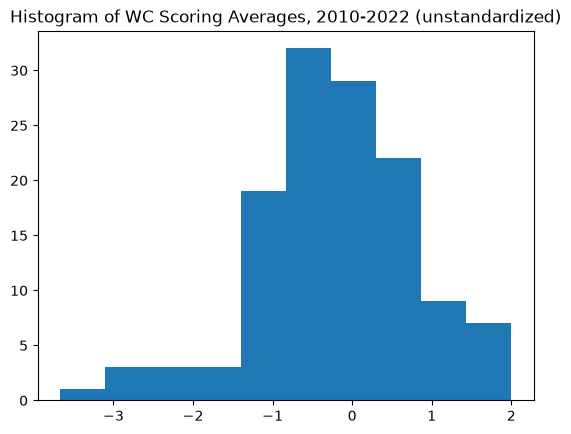

In [5]:
fig, ax = plt.subplots()
ax.hist(unstandardized_Y)
ax.set_title('Histogram of WC Scoring Averages, 2010-2022 (unstandardized)')
plt.show()

### Standardizing the Y vector
Inspecting the Y vector reveals that it has a mean slightly less than -0.2 and a standard deviation of approximately 0.98. That means that standardizing the data by subtracting the mean and dividing by the standard deviation only very slightly changes the values, but it's still best practice for modeling a continuous variable.

In [6]:
Y_mean = np.mean(unstandardized_Y)
Y_std_dev = np.std(unstandardized_Y)
# For simplicity, the standardized Y will be named simply Y
Y = (unstandardized_Y - Y_mean)/Y_std_dev
Y

array([ 0.88406598,  0.81582215, -0.8220296 ,  1.02055362, -0.8220296 ,
       -0.31020093,  0.54284686, -0.48081048, -0.31020093, -0.8220296 ,
        1.81023214,  0.40635921, -0.8220296 , -0.8220296 , -0.13959137,
        0.88406598, -3.55178252, -0.05428659, -0.05428659,  0.93281156,
        0.20162775, -0.48081048,  0.40635921,  1.73711376, -0.13959137,
       -0.31020093,  0.20162775, -0.48081048,  1.07904833,  0.20162775,
        0.20162775,  0.64033804,  0.20162775,  0.64033804, -1.84568694,
        0.81582215,  0.54284686, -0.09084578, -2.52812517,  0.71345642,
        1.8394795 ,  0.81582215, -0.13959137, -0.13959137,  0.20162775,
       -0.48081048,  1.22528509,  2.24894244, -0.13959137, -0.31020093,
       -1.84568694, -0.8220296 , -0.13959137, -1.16324871, -0.8220296 ,
        0.71345642,  1.81023214, -0.05428659, -1.16324871, -0.13959137,
       -0.8220296 ,  0.20162775, -0.05428659, -0.31020093,  1.02055362,
       -1.50446783, -1.16324871,  1.02055362, -0.48081048,  0.20

## Setup part 2: Creating the feature space


### Importing FIFA Rankings Point data

In [ ]:
fifa_rankings = pd.read_csv('fifa_ranking-2024-06-20.csv')
rpoints_list = []

#TODO: Identify last ranking date before 2014 and 2010 World Cups, then adapt code below

rankings_2018 = fifa_rankings[fifa_rankings['rank_date']=='2018-06-07']
for team in team_list_2018:
    for i in range(rankings_2018.shape[0]):
        if rankings_2018.iloc[i, 1].casefold() == team.casefold():
            rpoints_list.append(rankings_2018.iloc[i, 3])

rankings_2022 = fifa_rankings[fifa_rankings['rank_date']=='2022-10-06']
for team in team_list_2022:
    for i in range(rankings_2022.shape[0]):
        if rankings_2022.iloc[i, 1].casefold() == team.casefold():
            rpoints_list.append(rankings_2022.iloc[i, 3])

rpoints_list


Russia: 457.0
Saudi Arabia: 465.0
Egypt: 649.0
Uruguay: 1018.0
Morocco: 686.0
IR Iran: 708.0
Portugal: 1274.0
Spain: 1126.0
France: 1198.0
Australia: 718.0
Argentina: 1241.0
Iceland: 908.0
Peru: 1125.0
Denmark: 1051.0
Croatia: 945.0
Nigeria: 618.0
Costa Rica: 884.0
Serbia: 751.0
Germany: 1558.0
Mexico: 989.0
Brazil: 1431.0
Switzerland: 1199.0
Sweden: 880.0
Korea Republic: 544.0
Belgium: 1298.0
Panama: 571.0
Tunisia: 910.0
England: 1051.0
Colombia: 986.0
Japan: 521.0
Poland: 1183.0
Senegal: 838.0
QATAR: 1439.89
ENGLAND: 1728.47
SENEGAL: 1584.38
USA: 1627.48
ARGENTINA: 1773.88
DENMARK: 1666.57
MEXICO: 1644.89
FRANCE: 1759.78
MOROCCO: 1563.5
GERMANY: 1650.21
SPAIN: 1715.22
BELGIUM: 1816.71
SWITZERLAND: 1635.92
URUGUAY: 1638.71
PORTUGAL: 1676.56
BRAZIL: 1841.3
WALES: 1569.82
NETHERLANDS: 1694.51
TUNISIA: 1507.54
POLAND: 1548.59
JAPAN: 1559.54
CROATIA: 1645.64
CAMEROON: 1471.44
KOREA REPUBLIC: 1530.3
ECUADOR: 1464.39
IR IRAN: 1564.61
AUSTRALIA: 1488.72
SAUDI ARABIA: 1437.78
CANADA: 1475.0
C

[np.float64(457.0),
 np.float64(465.0),
 np.float64(649.0),
 np.float64(1018.0),
 np.float64(686.0),
 np.float64(708.0),
 np.float64(1274.0),
 np.float64(1126.0),
 np.float64(1198.0),
 np.float64(718.0),
 np.float64(1241.0),
 np.float64(908.0),
 np.float64(1125.0),
 np.float64(1051.0),
 np.float64(945.0),
 np.float64(618.0),
 np.float64(884.0),
 np.float64(751.0),
 np.float64(1558.0),
 np.float64(989.0),
 np.float64(1431.0),
 np.float64(1199.0),
 np.float64(880.0),
 np.float64(544.0),
 np.float64(1298.0),
 np.float64(571.0),
 np.float64(910.0),
 np.float64(1051.0),
 np.float64(986.0),
 np.float64(521.0),
 np.float64(1183.0),
 np.float64(838.0),
 np.float64(1439.89),
 np.float64(1728.47),
 np.float64(1584.38),
 np.float64(1627.48),
 np.float64(1773.88),
 np.float64(1666.57),
 np.float64(1644.89),
 np.float64(1759.78),
 np.float64(1563.5),
 np.float64(1650.21),
 np.float64(1715.22),
 np.float64(1816.71),
 np.float64(1635.92),
 np.float64(1638.71),
 np.float64(1676.56),
 np.float64(1841.3

### Aggregating T5League data

In [ ]:
# These arrays need to be in the same order as the team lists for each respective year
# Data transcribed by hand from fbref.com

EPL_10 = np.array([3, 3, 6, 2, 3, 0, 6, 4, 23, 7, 0, 4, 1, 3, 0, 0,
                    0, 2, 2, 4, 2, 5, 2, 3, 4, 2, 0, 3, 3, 2, 7, 0])
La_Liga_10 = np.array([1, 3, 0, 4, 2, 2, 3, 1, 0, 3, 0, 1, 0, 0, 0, 1,
                        0, 0, 2, 2, 0, 2, 1, 5, 2, 0, 0, 0, 20, 0, 0, 3])
Bundesliga_10 = np.array([3, 1, 0, 2, 3, 1, 2, 2, 0, 1, 23, 3, 2, 0, 0, 1,
                            0, 1, 1, 5, 0, 2, 3, 3, 5, 4, 3, 0, 0, 8, 3, 0])
Serie_A_10 = np.array([1, 6, 1, 8, 1, 2, 0, 4, 0, 0, 0, 3, 2, 2, 23, 1,
                        0, 0, 0, 2, 0, 0, 1, 1, 3, 1, 2, 0, 0, 4, 0, 4])
Ligue_1_10 = np.array([4, 1, 0, 1, 6, 0, 3, 0, 0, 11, 0, 1, 0, 0, 0, 2,
                        0, 1, 0, 0, 0, 3, 0, 0, 0, 1, 3, 0, 0, 2, 1, 1])

EPL_22 = np.array([0, 25, 6, 6, 5, 7, 1, 5, 2, 4, 5, 7, 5, 3, 10, 12,
                9, 3, 0, 2, 2, 2, 1, 2, 3, 1, 0, 0, 0, 0, 5, 1])
La_Liga_22 = np.array([0, 0, 3, 2, 10, 4, 1, 5, 4, 2, 18, 4, 1, 4, 2, 5,
                    0, 2, 0, 1, 1, 3, 0, 1, 1, 0, 1, 0, 0, 0, 2, 6])
Bundesliga_22 = np.array([0, 1, 1, 2, 1, 6, 0, 6, 1, 20, 1, 3, 7, 0, 2, 0,
                        0, 2, 1, 2, 7, 5, 1, 2, 2, 1, 0, 0, 1, 0, 1, 1])
Serie_A_22 = np.array([0, 0, 2, 2, 4, 2, 2, 3, 2, 0, 0, 2, 2, 3, 2, 3,
                    1, 4, 1, 9, 0, 4, 4, 1, 0, 0, 1, 0, 0, 0, 0, 11])
Ligue_1_22 = np.array([0, 0, 5, 1, 2, 1, 0, 6, 5, 0, 2, 3, 2, 0, 3, 2,
                    2, 0, 2, 2, 3, 1, 4, 0, 1, 0, 0, 0, 2, 1, 5, 0])
